# Week 6 — Embedding Manipulation Evaluation

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

> **Prerequisites:** week5_embeddings_colab ✓ (needs week5_img_embeddings.npy)

**What this does:**
- Applies COCO-grounded direction vectors to all 100 test images
- Computes BLEU-4 + CLIP score for steered captions
- Generates before/after caption grid (dissertation Figure 3)
- Adds embedding manipulation row to results_table.csv

**Literature:** Radford et al. (2021) CLIP · Suzuki & Matsuo (2022)

**Run order every session:** Cell 1 → Cell 2 → Cell 3 → Cell 4 onwards


In [1]:
# ── CELL 1 — Mount Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate
!pip install -q sentencepiece nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
import transformers
print(f'transformers: {transformers.__version__}')
print('Ready.')

transformers: 5.12.1
Ready.


In [3]:
# ── CELL 3 — Paths ────────────────────────────────────────────────────────
import os

BASE           = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR  = f'{BASE}/data/processed'
COCO_INST_FILE = f'{BASE}/data/coco/annotations/instances_val2017.json'
RESULTS_DIR    = f'{BASE}/results'
TARGET_CAT     = 'person'
STEER_STRENGTH = 0.3

print('Required files check:')
all_ok = True
for f in [f'{PROCESSED_DIR}/test.csv',
          f'{RESULTS_DIR}/week5_img_embeddings.npy',
          f'{RESULTS_DIR}/week3_baseline.csv']:
    ok = os.path.exists(f)
    print(f'  {"OK" if ok else "MISSING"} : {os.path.basename(f)}')
    if not ok: all_ok = False
if not all_ok:
    print('Run week3 and week5 notebooks first.')
else:
    print('All good. Proceed to Cell 4.')

Required files check:
  OK : test.csv
  OK : week5_img_embeddings.npy
  OK : week3_baseline.csv
All good. Proceed to Cell 4.


In [4]:
# ── CELL 4 — Imports ──────────────────────────────────────────────────────
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import CLIPProcessor, CLIPModel

print('All imports done.')

All imports done.


In [5]:
# ── CELL 5 — Load embeddings + data ──────────────────────────────────────
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
img_embs = np.load(f'{RESULTS_DIR}/week5_img_embeddings.npy')
print(f'Test images  : {len(test_df)}')
print(f'Embeddings   : {img_embs.shape}')

Test images  : 100
Embeddings   : (100, 512)


In [6]:
# ── CELL 6 — Load CLIP ────────────────────────────────────────────────────
print('Loading CLIP (Radford et al., 2021)...')
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
dev        = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model = clip_model.to(dev).eval()
print(f'CLIP on {dev}.')

Loading CLIP (Radford et al., 2021)...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP on cuda.


In [7]:
# ── CELL 7 — Metrics functions ────────────────────────────────────────────
def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(sentence_bleu([r.lower().split() for r in refs], gen.lower().split(), smoothing_function=s), 4)

def compute_bleu(generated, references):
    s    = SmoothingFunction().method1
    hyps = [g.lower().split() for g in generated]
    refs = [[r.lower().split() for r in rs] for rs in references]
    return {
        'bleu_1': round(corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=s), 4),
        'bleu_4': round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4),
    }

def compute_clip_scores_batch(images, captions, batch_size=16):
    scores = []
    for i in range(0, len(images), batch_size):
        b_imgs, b_caps = images[i:i+batch_size], captions[i:i+batch_size]
        inp = clip_proc(text=b_caps, images=b_imgs, return_tensors='pt',
                        padding=True, truncation=True, max_length=77)
        inp = {k: v.to(dev) for k, v in inp.items()}
        with torch.no_grad():
            out   = clip_model(**inp)
            i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
            scores.extend((i_emb * t_emb).sum(dim=-1).tolist())
    return [round(s, 4) for s in scores]

print('Metrics ready.')

Metrics ready.


In [8]:
# ── CELL 8 — Compute COCO-grounded direction (Fix 3) ─────────────────────
def load_coco_category_sets(df):
    if not os.path.exists(COCO_INST_FILE): return {}
    with open(COCO_INST_FILE) as f:
        inst = json.load(f)
    cat_map, sampled_ids = {c['id']: c['name'] for c in inst['categories']}, set(df['image_id'].tolist())
    cat_sets = defaultdict(set)
    for ann in inst['annotations']:
        if ann['image_id'] in sampled_ids:
            cat_sets[cat_map[ann['category_id']]].add(ann['image_id'])
    return dict(cat_sets)

def compute_coco_direction(img_embeddings, df, category_name, cat_sets):
    if category_name not in cat_sets: return None
    with_ids    = cat_sets[category_name]
    without_ids = set(df['image_id'].tolist()) - with_ids
    with_mask   = df['image_id'].isin(with_ids).values
    wo_mask     = df['image_id'].isin(without_ids).values
    if with_mask.sum() < 5 or wo_mask.sum() < 5: return None
    d = img_embeddings[with_mask].mean(0) - img_embeddings[wo_mask].mean(0)
    return d / np.linalg.norm(d)

def steer_embedding(emb, direction, strength=STEER_STRENGTH):
    s = emb + strength * direction
    return s / np.linalg.norm(s)

cat_sets  = load_coco_category_sets(test_df)
direction = compute_coco_direction(img_embs, test_df, TARGET_CAT, cat_sets)
if direction is not None:
    print(f'Direction computed: -> {TARGET_CAT}')
else:
    print(f'Could not compute direction for {TARGET_CAT}. Check COCO instances file.')

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Direction computed: -> person


In [9]:
# ── CELL 9 — Generate steered captions ───────────────────────────────────
# Steer each image embedding -> nearest neighbour -> its caption.
# Retrieval-based approximation (stated as limitation in methodology).

if direction is None:
    raise RuntimeError('Direction not computed. Check Cell 8.')

print(f'Steering all {len(test_df)} images toward: {TARGET_CAT}')
steered_captions = []
for i in tqdm(range(len(test_df)), desc='Steering'):
    steered = steer_embedding(img_embs[i], direction)
    sims    = img_embs @ steered
    nearest = int(np.argmax(sims))
    steered_captions.append(test_df.iloc[nearest]['captions'].split(' | ')[0])

print(f'Generated {len(steered_captions)} steered captions.')

Steering all 100 images toward: person



Steering: 100%|██████████| 100/100 [00:00<00:00, 10622.79it/s]

Generated 100 steered captions.


In [10]:
# ── CELL 10 — Evaluate steered captions ──────────────────────────────────
print('Computing CLIP scores for steered captions...')
images = [Image.open(p).convert('RGB') for p in test_df['img_path']]
clip_scores = compute_clip_scores_batch(images, steered_captions)

results_df = test_df[['image_id','img_path','captions']].copy()
results_df['steered_caption'] = steered_captions
results_df['references']      = results_df['captions']
results_df['clip_score']      = clip_scores
results_df['bleu4'] = [
    compute_sentence_bleu(gen, refs.split(' | '))
    for gen, refs in zip(steered_captions, results_df['captions'])
]

results_df.to_csv(f'{RESULTS_DIR}/week6_embedding_results.csv', index=False)
print(f'Mean CLIP score: {results_df["clip_score"].mean():.4f}')
print(f'Mean BLEU-4    : {results_df["bleu4"].mean():.4f}')

Computing CLIP scores for steered captions...
Mean CLIP score: 0.2969
Mean BLEU-4    : 1.0000


In [11]:
# ── CELL 11 — Update results_table.csv ───────────────────────────────────
bleu = compute_bleu(steered_captions, [r.split(' | ') for r in results_df['captions']])
agg  = {
    'technique':       f'Embedding manipulation (COCO -> {TARGET_CAT})',
    'bleu_1':          bleu['bleu_1'],
    'bleu_4':          bleu['bleu_4'],
    'clip_score_mean': round(results_df['clip_score'].mean(), 4),
    'clip_score_std':  round(results_df['clip_score'].std(),  4),
    'n_samples':       len(results_df),
}

agg_path = f'{RESULTS_DIR}/results_table.csv'
existing = pd.read_csv(agg_path) if os.path.exists(agg_path) else pd.DataFrame()
updated  = pd.concat([existing, pd.DataFrame([agg])], ignore_index=True)
updated.to_csv(agg_path, index=False)
print('Updated results_table.csv:')
print(updated[['technique','bleu_4','clip_score_mean']].to_string(index=False))

Updated results_table.csv:
                              technique  bleu_4  clip_score_mean
             Baseline (zero-shot LLaVA)  0.0213           0.3173
                     Hard: object_focus  0.0386           0.3261
                     Hard: style_formal  0.0226           0.3202
                     Hard: style_simple  0.3665           0.2998
                   Hard: attribute_rich  0.0235           0.3202
                     Hard: action_focus  0.0379           0.3276
                  Expert: expert_vision  0.0349           0.3256
                  Expert: expert_domain  0.0313           0.3288
                    Expert: expert_coco  0.1492           0.3233
                Soft prompt (10 tokens)  0.0310           0.3266
Embedding manipulation (COCO -> person)  1.0000           0.2969


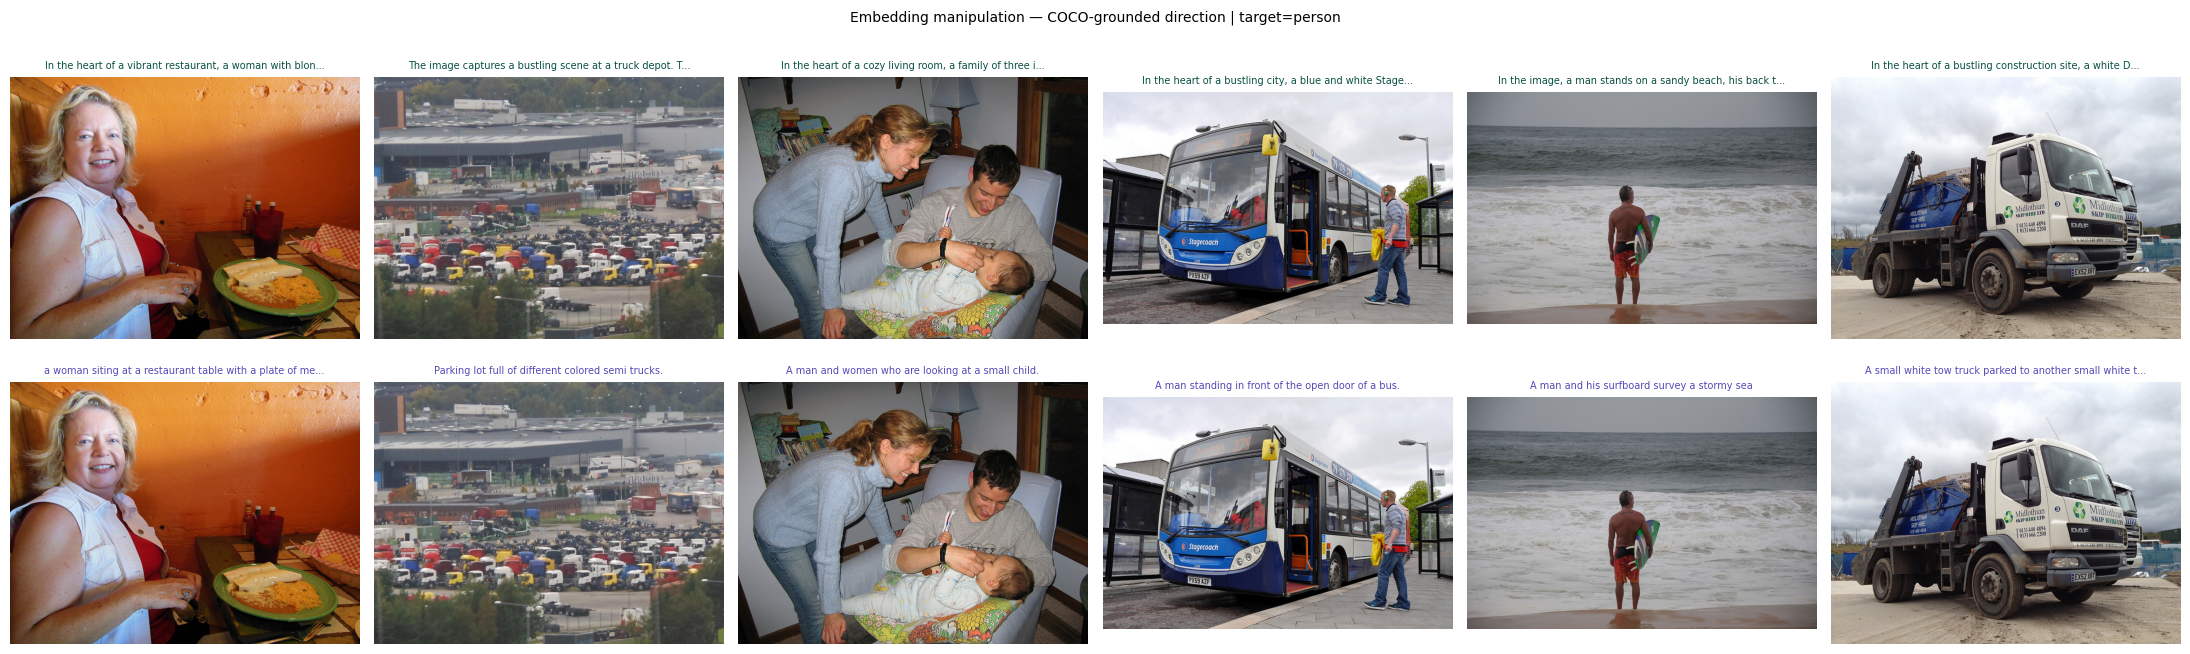

Saved: /content/drive/MyDrive/dissertation_final/results/week6_before_after_grid.png


In [12]:
# ── CELL 12 — Before/after grid (Figure 3) ───────────────────────────────
baseline_df = pd.read_csv(f'{RESULTS_DIR}/week3_baseline.csv')
merged = results_df.merge(
    baseline_df[['image_id','generated']].rename(columns={'generated':'baseline_caption'}),
    on='image_id', how='inner'
).sample(6, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
for col, (_, row) in enumerate(merged.iterrows()):
    img = Image.open(row['img_path']).convert('RGB')
    for r in [0, 1]:
        axes[r, col].imshow(img)
        axes[r, col].axis('off')
    cap0 = row['baseline_caption']
    cap1 = row['steered_caption']
    axes[0, col].set_title((cap0[:55]+'...') if len(cap0)>55 else cap0, fontsize=7, color='#085041')
    axes[1, col].set_title((cap1[:55]+'...') if len(cap1)>55 else cap1, fontsize=7, color='#534AB7')
axes[0,0].set_ylabel('Baseline', color='#085041', fontsize=9)
axes[1,0].set_ylabel(f'Steered -> {TARGET_CAT}', color='#534AB7', fontsize=9)
plt.suptitle(f'Embedding manipulation — COCO-grounded direction | target={TARGET_CAT}', fontsize=10)
plt.tight_layout()
out = f'{RESULTS_DIR}/week6_before_after_grid.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [13]:
# ── CELL 13 — Final verification ──────────────────────────────────────────
print('='*55)
print('Week 6 — Final verification')
print('='*55)
for f in [f'{RESULTS_DIR}/week6_embedding_results.csv',
          f'{RESULTS_DIR}/week6_before_after_grid.png',
          f'{RESULTS_DIR}/results_table.csv']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(f):40s} {size:>10,} bytes')
print()
print(f'CLIP score mean : {results_df["clip_score"].mean():.4f}')
print(f'BLEU-4 mean     : {results_df["bleu4"].mean():.4f}')
print()
print('Week 6 complete. Next: week7_lora_colab.ipynb')

Week 6 — Final verification
  [OK] week6_embedding_results.csv                  70,566 bytes
  [OK] week6_before_after_grid.png               4,436,116 bytes
  [OK] results_table.csv                               659 bytes

CLIP score mean : 0.2969
BLEU-4 mean     : 1.0000

Week 6 complete. Next: week7_lora_colab.ipynb
